<a href="https://colab.research.google.com/github/dhruv-verma-sys/geostorm/blob/main/ML_exp_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/historical_automobile_sales.csv"

df = pd.read_csv(url)

df.head()

,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1/31/1980,1980,Jan,1,108.24,0.50,27483.571,1558,7,60.223,0.010000,5.4,456.0,Supperminicar,Georgia
1,2/29/1980,1980,Feb,1,98.75,0.75,24308.678,3048,4,45.986,-0.309594,4.8,555.9,Supperminicar,New York
2,3/31/1980,1980,Mar,1,107.48,0.20,28238.443,3137,3,35.141,-0.308614,3.4,620.0,Mediumfamilycar,New York
3,4/30/1980,1980,Apr,1,115.01,1.00,32615.149,1653,7,45.673,0.230596,4.2,702.8,Supperminicar,Illinois
4,5/31/1980,1980,May,1,98.72,0.20,23829.233,1319,4,52.997,0.138197,5.3,770.4,Smallfamiliycar,California


In [30]:
print(df.shape)
print(df.columns.tolist())

(528, 15)
['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence', 'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition', 'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales', 'Vehicle_Type', 'City']


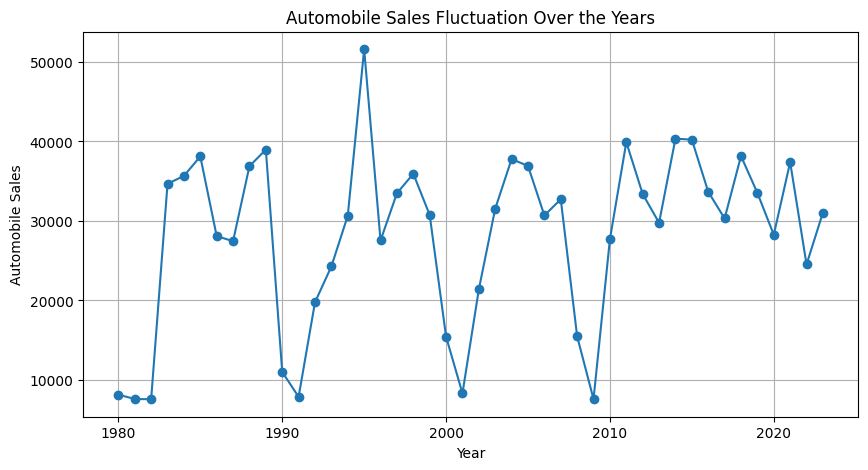

In [31]:
yearly_sales = df.groupby('Year')['Automobile_Sales'].sum()

plt.figure(figsize=(10,5))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o')

plt.xlabel('Year')
plt.ylabel('Automobile Sales')
plt.title('Automobile Sales Fluctuation Over the Years')

plt.grid(True)
plt.show()

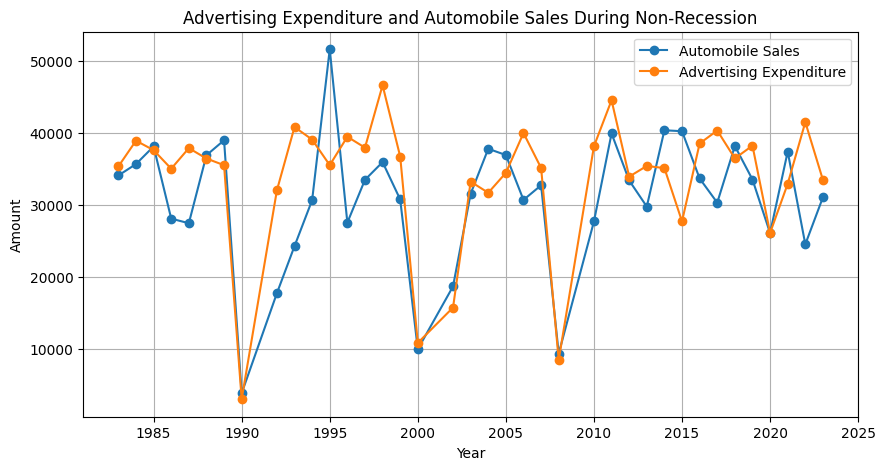

In [32]:
non_recession = df[df['Recession'] == 0]

data = non_recession.groupby('Year')[
    ['Automobile_Sales', 'Advertising_Expenditure']
].sum()

plt.figure(figsize=(10,5))

plt.plot(
    data.index,
    data['Automobile_Sales'],
    marker='o',
    label='Automobile Sales'
)

plt.plot(
    data.index,
    data['Advertising_Expenditure'],
    marker='o',
    label='Advertising Expenditure'
)

plt.xlabel('Year')
plt.ylabel('Amount')
plt.title('Advertising Expenditure and Automobile Sales During Non-Recession')

plt.legend()
plt.grid(True)
plt.show()

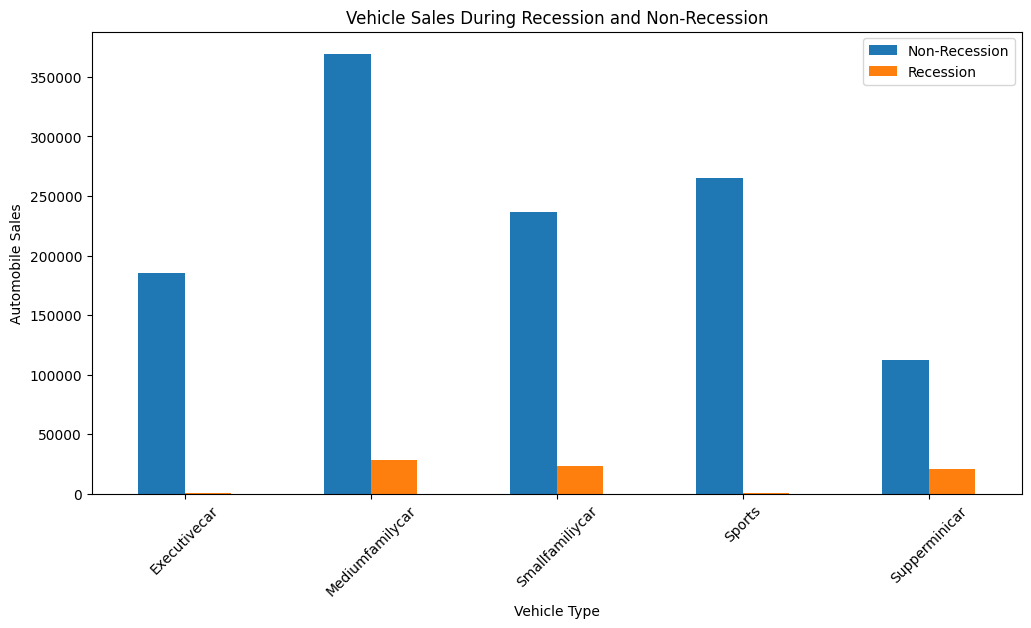

In [34]:
data = df.groupby(
    ['Vehicle_Type', 'Recession']
)['Automobile_Sales'].sum().unstack()

data.plot(
    kind='bar',
    figsize=(12,6)
)

plt.xlabel('Vehicle Type')
plt.ylabel('Automobile Sales')
plt.title('Vehicle Sales During Recession and Non-Recession')

plt.xticks(rotation=45)
plt.legend(['Non-Recession', 'Recession'])

plt.show()

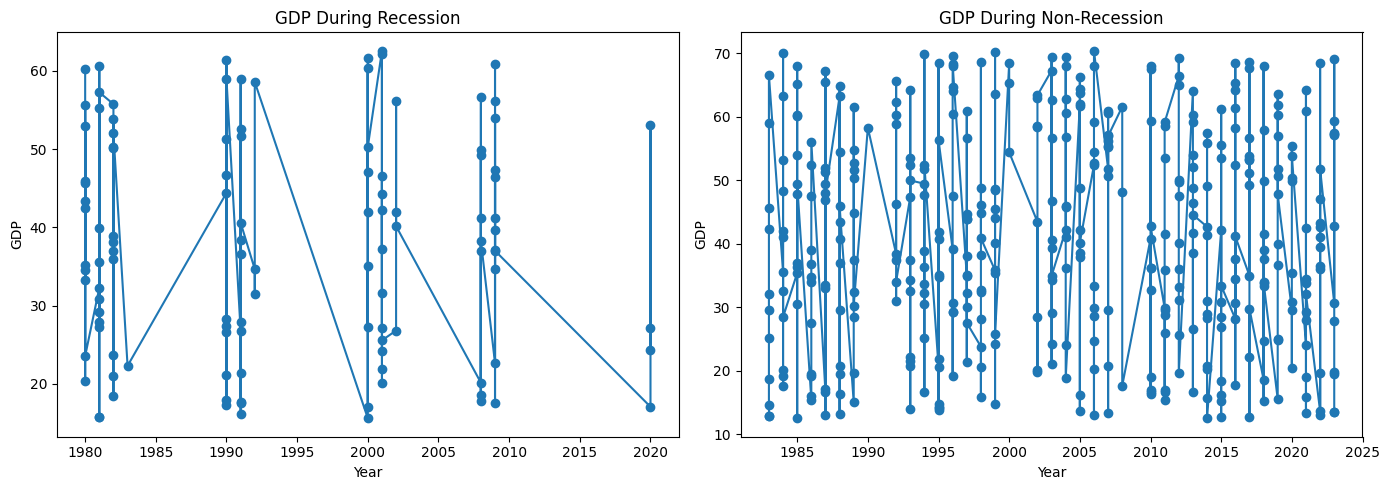

In [35]:
recession = df[df['Recession'] == 1]
non_recession = df[df['Recession'] == 0]

fig, ax = plt.subplots(1, 2, figsize=(14,5))

ax[0].plot(
    recession['Year'],
    recession['GDP'],
    marker='o'
)

ax[0].set_title('GDP During Recession')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('GDP')

ax[1].plot(
    non_recession['Year'],
    non_recession['GDP'],
    marker='o'
)

ax[1].set_title('GDP During Non-Recession')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('GDP')

plt.tight_layout()
plt.show()

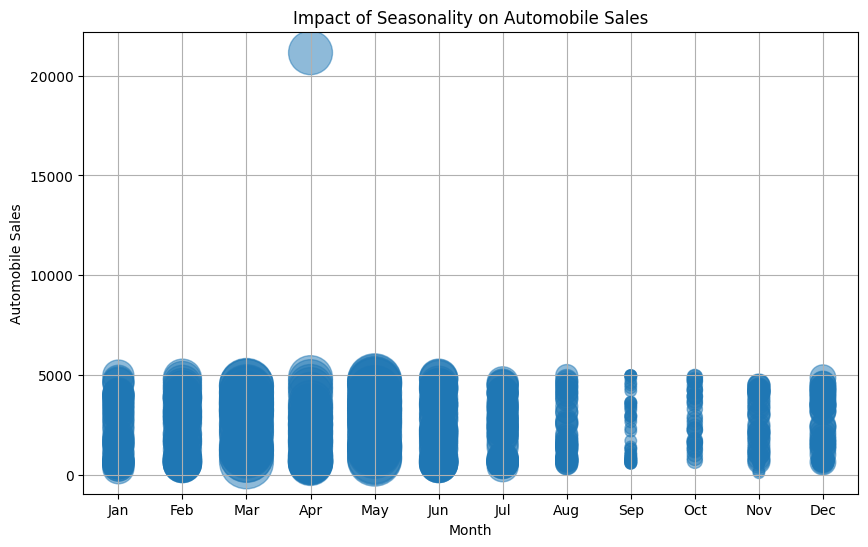

In [36]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Month'],
    df['Automobile_Sales'],
    s=df['Seasonality_Weight'] * 1000,
    alpha=0.5
)

plt.xlabel('Month')
plt.ylabel('Automobile Sales')
plt.title('Impact of Seasonality on Automobile Sales')

plt.grid(True)
plt.show()

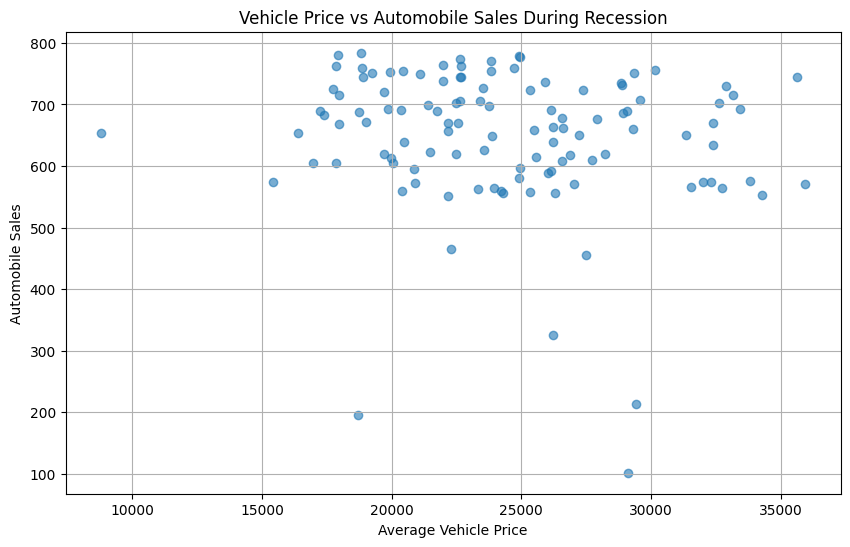

In [37]:
recession = df[df['Recession'] == 1]

plt.figure(figsize=(10,6))

plt.scatter(
    recession['Price'],
    recession['Automobile_Sales'],
    alpha=0.6
)

plt.xlabel('Average Vehicle Price')
plt.ylabel('Automobile Sales')
plt.title('Vehicle Price vs Automobile Sales During Recession')

plt.grid(True)
plt.show()

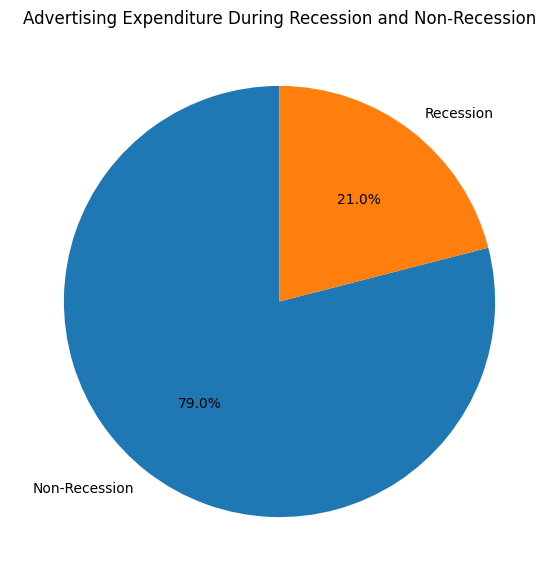

In [38]:
data = df.groupby('Recession')['Advertising_Expenditure'].sum()

plt.figure(figsize=(7,7))

plt.pie(
    data,
    labels=['Non-Recession', 'Recession'],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Advertising Expenditure During Recession and Non-Recession')

plt.show()

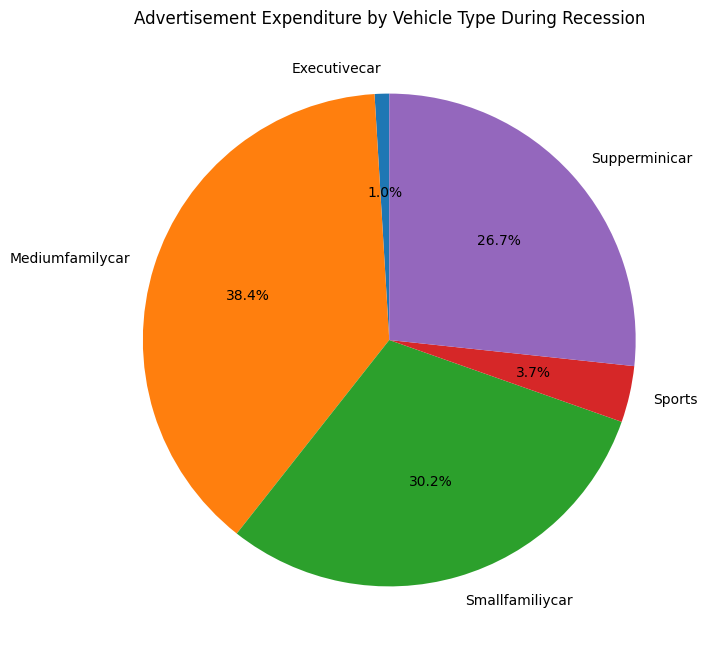

In [39]:
recession = df[df['Recession'] == 1]

data = recession.groupby(
    'Vehicle_Type'
)['Advertising_Expenditure'].sum()

plt.figure(figsize=(8,8))

plt.pie(
    data,
    labels=data.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Advertisement Expenditure by Vehicle Type During Recession')

plt.show()

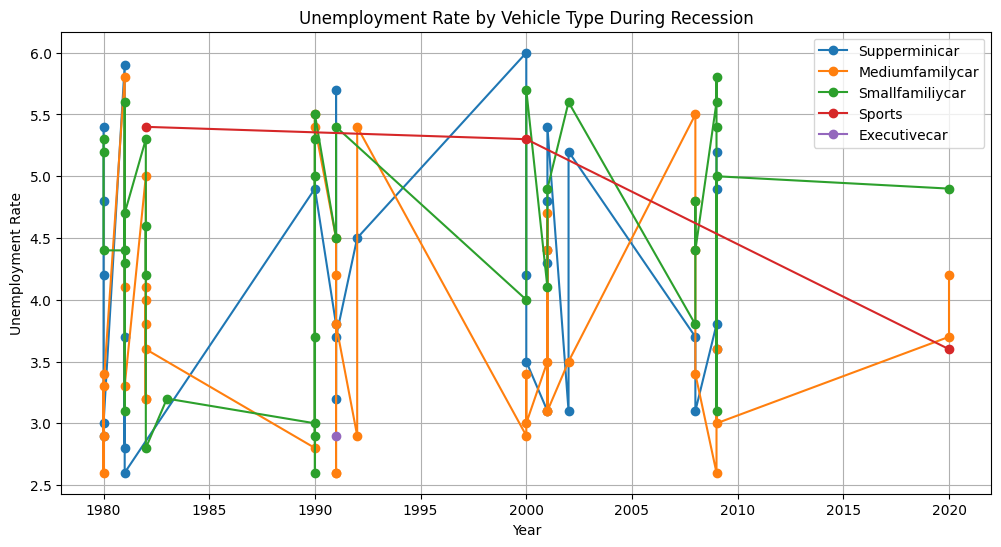

In [40]:
recession = df[df['Recession'] == 1]

plt.figure(figsize=(12,6))

for vehicle in recession['Vehicle_Type'].unique():

    data = recession[
        recession['Vehicle_Type'] == vehicle
    ]

    plt.plot(
        data['Year'],
        data['unemployment_rate'],
        marker='o',
        label=vehicle
    )

plt.xlabel('Year')
plt.ylabel('Unemployment Rate')
plt.title('Unemployment Rate by Vehicle Type During Recession')

plt.legend()
plt.grid(True)

plt.show()